In [ ]:
import cn2an
import logging
from utils import pre_process, pre_process_without_n

In [41]:
import os
if not os.path.exists('../sample'):
    print('No Sample Found')
    quit()
else:
    docs = os.listdir(os.path.join(os.getcwd(), '..', 'sample'))
    docs = [f for f in docs if f.endswith('.txt')]
    print(f'Found {len(docs)} Samples')

Found 453 Samples


In [62]:
import re
def rule1(text):
    lines = text.split('\n')
    matches = []
    rule1_keywords = r"(?:^|,)\s*现将|(?:^|,)\s*现就|现.*?如下|(?:^|,)\s*为[^,]*?落实|(?:^|,)\s*为[^,]*?贯彻|(?:^|,)\s*为规范|(?:^|,)\s*为了规范"
    rule1_regex = re.compile(rule1_keywords)
    for line in lines:
        if len(line.strip()) > 0:
            sentences = line.split('。')
            for sentence in sentences:
                sentenceMatch = rule1_regex.search(sentence)
                if sentenceMatch is not None:
                    matches.append((sentence.strip(), sentenceMatch.group().strip()))
    return matches

In [64]:
# test rule 1 on a random sample
import random
doc = ''
idx = random.randrange(0, len(docs))
print(f'Select {idx}-th doc {docs[idx]}.')
with open(os.path.join(os.getcwd(), '..', 'sample', docs[idx]), 'r', encoding='utf-8') as f:
    doc = f.read()
    print(rule1(doc))

Select 128-th doc 吉林市教育局关于进一步加强疫情防控宣传工作...(FBM-CLI.12.6037978).txt.
[('为凝聚打赢疫情防控阻击战的强大合力，营造抗击疫情的浓厚氛围，现就进一步加强疫情防控宣传工作通知如下：', '现就进一步加强疫情防控宣传工作通知如下')]


In [65]:
# run rule 1 on all samples
resultsAll = {}
for i in range(len(docs)):
    with open(os.path.join(os.getcwd(), '..', 'sample', docs[i]), 'r', encoding='utf-8') as f:
        text = f.read()
        resultsLocal = rule1(text)
        resultsAll[i] = resultsLocal

Found 171 documents without matched text out of 453 documents.


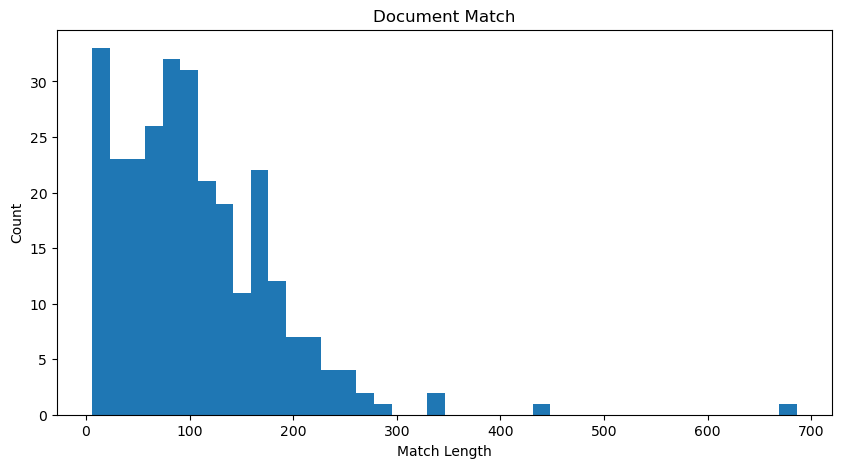

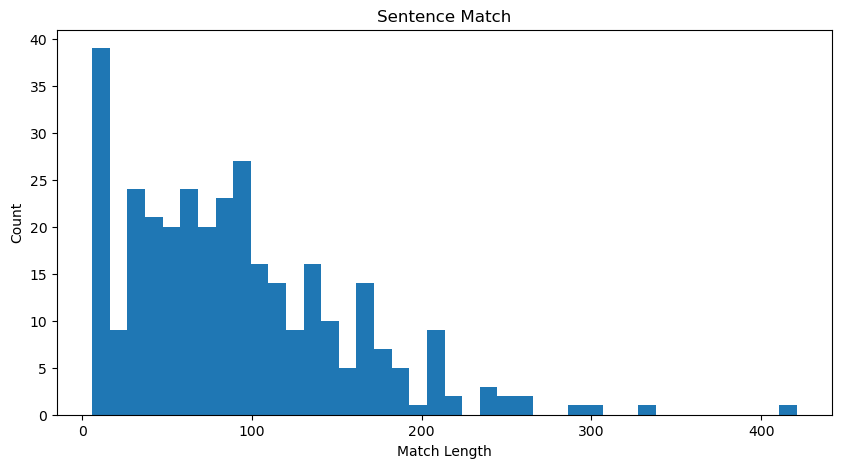

In [69]:
# check matching results
from matplotlib import pyplot as plt
noneCount = 0
docLengths = []
sentLengths = []
for i in resultsAll:
    if len(resultsAll[i]) == 0:
        noneCount += 1
        continue
    lenDoc = 0
    for e in resultsAll[i]:
        lenDoc += len(e[0])
        sentLengths.append(len(e[0]))
    docLengths.append(lenDoc)
print(f'Found {noneCount} documents without matched text out of {len(docs)} documents.')
docLengths = sorted(docLengths, reverse=True)
sentLengths = sorted(sentLengths, reverse=True)
def drawHist(data, title=''):
    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=40)
    plt.xlabel('Match Length')
    plt.ylabel('Count')
    if len(title) > 0:
        plt.title(title)
    plt.show()
drawHist(docLengths, 'Document Match')
drawHist(sentLengths, 'Sentence Match')

In [ ]:

def find_col07_rule_base(docs):
    """
    Returns:
        list of tuple: the all sentences that match 一般政策语言 keywords and the matched keywords
        list of tuple: the index of the matched sentences in the original text
    """
    
    logging.getLogger().setLevel(logging.ERROR)
    
    rule_1_keywords =["(?:^|,)\s*现将","(?:^|,)\s*现就","现.*?如下","(?:^|,)\s*为[^,]*?落实","(?:^|,)\s*为[^,]*?贯彻", "(?:^|,)\s*为规范","(?:^|,)\s*为了规范"]
    rule_1_pattern = re.compile('|'.join(rule_1_keywords))
    rule_1_keywords_fuzzy = ["现提出","提出如下","提出以下"]
    
    rule_2_keywords = ["胡锦涛", "温家宝", "习近平", "李克强", "党中央", "国务院"]
    
    rule_3_keyword = ["总\s*则","指导思想", "基本原则"]
    
    paragraphs = pre_process(docs)
    matched_paragraphs = []
    i = 0
    while i < len(paragraphs):
        paragraph = paragraphs[i]
        if rule_1_pattern.search(paragraph):
            if len(paragraph.strip()) <= 15:
                try:
                    previous_paragraph = paragraphs[i-1]
                    matched_paragraphs.append((previous_paragraph + "。" + paragraph.strip(), rule_1_pattern.search(paragraph).group()))
                except:
                    matched_paragraphs.append((paragraph.strip(), rule_1_pattern.search(paragraph).group()))
            else:
                matched_paragraphs.append((paragraph.strip(), rule_1_pattern.search(paragraph).group()))
        elif any(keyword in paragraph for keyword in rule_1_keywords_fuzzy):
            if len(paragraph.strip()) <= 15:
                try:
                    previous_paragraph = paragraphs[i-1]
                    matched_paragraphs.append((previous_paragraph + "。" + paragraph.strip(), [keyword for keyword in rule_1_keywords_fuzzy if keyword in paragraph][0]))
                except:
                    matched_paragraphs.append((paragraph.strip(), [keyword for keyword in rule_1_keywords_fuzzy if keyword in paragraph][0]))
            else:
                matched_paragraphs.append((paragraph.strip(), [keyword for keyword in rule_1_keywords_fuzzy if keyword in paragraph][0]))
        elif any(keyword in paragraph for keyword in rule_2_keywords):
            matched_paragraphs.append((paragraph.strip(), [keyword for keyword in rule_2_keywords if keyword in paragraph][0]))
        elif re.search('|'.join(rule_3_keyword), paragraph):
            temp = []
            temp += [paragraph]
            
            # number = ['1','2','3','4','5','6','7','8','9']
            number_pattern = re.compile(r'\d+')
            
            # number_chinese = ["一","二","三","四","五","六","七","八","九"]
            number_chinese_pattern = re.compile(r'(?:(?:[一二三四五六七八九]十)?[一二三四五六七八九]|十[一二三四五六七八九]?|二十|三十|四十|五十|六十|七十|八十|九十)')
            
            end_word = None
            try:
                if re.search(number_pattern, paragraph):
                    number = re.search(number_pattern, paragraph).group()
                    index = paragraph.index(number)

                    target_number = str(int(number) + 1)
                    target_number = str(target_number)

                    end_word = target_number + paragraph[index + len(number)]
                
                elif number_chinese_pattern.search(paragraph):
                    number = re.search(number_chinese_pattern, paragraph).group()
                    index = paragraph.index(number)

                    number_int = cn2an.cn2an(number)
                    number_int += 1
                    target_number = cn2an.an2cn(number_int)

                    end_word = target_number + paragraph[index + len(number)]
            except:
                pass
            
            if end_word:
                reach_end = True
                
                i += 1
                while i < len(paragraphs) and reach_end:
                    if end_word in paragraphs[i]:
                        reach_end = False
                        break
                    temp += [paragraphs[i]]
                    i += 1
                    
                if reach_end == False:
                    # add list 
                    for index, sentence in enumerate(temp):
                        if index == 0:
                            matched_paragraphs.append((sentence, re.search('|'.join(rule_3_keyword), sentence).group()))
                        else:
                            matched_paragraphs.append((sentence, "总则/指导思想/基本原则内容"))
                else:
                    temp = [paragraph]
                    next_index = paragraphs.index(paragraph) + 1
                    if next_index < len(paragraphs):
                        temp += [paragraphs[next_index]]
                        for index, sentence in enumerate(temp):
                            if index == 0:
                                matched_paragraphs.append((sentence, re.search('|'.join(rule_3_keyword), sentence).group()))
                            else:
                                matched_paragraphs.append((sentence, "总则/指导思想/基本原则内容"))
                    else:
                        matched_paragraphs.append((paragraph.strip(), [keyword for keyword in rule_3_keyword if keyword in paragraph][0]))
                    i = next_index
                    
            else:
                temp = [paragraph]
                next_index = paragraphs.index(paragraph) + 1
                if next_index < len(paragraphs):
                    temp += [paragraphs[next_index]]
                    for index, sentence in enumerate(temp):
                        if index == 0:
                            matched_paragraphs.append((sentence, re.search('|'.join(rule_3_keyword), sentence).group()))
                        else:
                            matched_paragraphs.append((sentence, "总则/指导思想/基本原则内容"))
                        
                else:
                    matched_paragraphs.append((paragraph.strip(), [keyword for keyword in rule_3_keyword if keyword in paragraph][0]))
                i = next_index
                
        i += 1
    
    if len(matched_paragraphs) == 0:
        # print("No matched information found, using default rule")
        # find the first sentence in docs that have \u3000\u3000
        for paragraph in paragraphs:
            if "\u3000\u3000" in paragraph:
                if len(paragraph) > 5:
                    matched_paragraphs.append((paragraph.strip(), "默认规则"))
                break
    
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index
